# Module 4 — Impact Analysis of Data Poisoning Attacks
This notebook analyzes the impact of label flipping attacks (targeted and random) across different configurations.

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.patches as mpatches
from torchvision import datasets, transforms

base = r"E:\Me\coding\8th Sem\Final Project\Codes\Fe-Learn-Datapoisoing\evaluation"
data_path = r"E:\Me\coding\8th Sem\Final Project\Codes\Fe-Learn-Datapoisoing\data"

def load(filename):
    path = os.path.join(base, filename)
    with open(path) as f:
        return json.load(f)

def load_safe(filename):
    """Load file if exists, return None if not found."""
    path = os.path.join(base, filename)
    if not os.path.exists(path):
        print(f"Warning: {filename} not found — skipping.")
        return None
    with open(path) as f:
        return json.load(f)

def get_acc(data):
    if data is None:
        return [0] * 20
    return [r[1]*100 for r in data['accuracy']]

def get_loss(data):
    if data is None:
        return [0] * 20
    return [r[1] for r in data['loss']]

def get_asr(data):
    if data is None or 'asr' not in data:
        return [0] * 20
    return [r[1]*100 if r[1] is not None else 0 for r in data['asr']]

def get_drop(data):
    if data is None or 'accuracy_drop' not in data:
        return [None] * 20
    return [r[1]*100 if r[1] is not None else None for r in data['accuracy_drop']]

def get_final_per_class(data):
    if data is None or 'per_class_accuracy' not in data:
        return None
    return [x * 100 for x in data['per_class_accuracy'][-1][1]]

def final_acc(data):
    if data is None:
        return 0.0
    return data['accuracy'][-1][1] * 100

def final_asr(data):
    if data is None or 'asr' not in data or not data['asr']:
        return 0.0
    v = data['asr'][-1][1]
    return v * 100 if v is not None else 0.0

rounds = list(range(1, 21))
print('Imports and helpers done.')

Imports and helpers done.


In [2]:
# Baselines — use load() since these always exist
mnist_mlp_iid_clean    = load('mnist_mlp_iid_results.json')
mnist_mlp_noniid_clean = load('mnist_mlp_noniid_results.json')
mnist_cnn_iid_clean    = load('mnist_cnn_iid_results.json')
mnist_cnn_noniid_clean = load('mnist_cnn_noniid_results.json')
emnist_mlp_iid_clean   = load('emnist_mlp_iid_results.json')
emnist_mlp_noniid_clean= load('emnist_mlp_noniid_results.json')
emnist_cnn_iid_clean   = load('emnist_cnn_iid_results.json')
emnist_cnn_noniid_clean= load('emnist_cnn_noniid_results.json')

# MNIST Attacks — use load() since these exist
mlp_iid_t1 = load('mnist_mlp_iid_attack_targeted_1.json')
mlp_iid_t3 = load('mnist_mlp_iid_attack_targeted_3.json')
mlp_iid_t5 = load('mnist_mlp_iid_attack_targeted_5.json')
mlp_iid_r1 = load('mnist_mlp_iid_attack_random_1.json')
mlp_iid_r3 = load('mnist_mlp_iid_attack_random_3.json')
mlp_iid_r5 = load('mnist_mlp_iid_attack_random_5.json')

mlp_noniid_t1 = load('mnist_mlp_noniid_attack_targeted_1.json')
mlp_noniid_t3 = load('mnist_mlp_noniid_attack_targeted_3.json')
mlp_noniid_t5 = load('mnist_mlp_noniid_attack_targeted_5.json')
mlp_noniid_r1 = load('mnist_mlp_noniid_attack_random_1.json')
mlp_noniid_r3 = load('mnist_mlp_noniid_attack_random_3.json')
mlp_noniid_r5 = load('mnist_mlp_noniid_attack_random_5.json')

cnn_iid_t1 = load('mnist_cnn_iid_attack_targeted_1.json')
cnn_iid_t3 = load('mnist_cnn_iid_attack_targeted_3.json')
cnn_iid_t5 = load('mnist_cnn_iid_attack_targeted_5.json')
cnn_iid_r1 = load('mnist_cnn_iid_attack_random_1.json')
cnn_iid_r3 = load('mnist_cnn_iid_attack_random_3.json')
cnn_iid_r5 = load('mnist_cnn_iid_attack_random_5.json')

cnn_noniid_t1 = load('mnist_cnn_noniid_attack_targeted_1.json')
cnn_noniid_t3 = load('mnist_cnn_noniid_attack_targeted_3.json')
cnn_noniid_t5 = load('mnist_cnn_noniid_attack_targeted_5.json')
cnn_noniid_r1 = load('mnist_cnn_noniid_attack_random_1.json')
cnn_noniid_r3 = load('mnist_cnn_noniid_attack_random_3.json')
cnn_noniid_r5 = load('mnist_cnn_noniid_attack_random_5.json')

# EMNIST Attacks — use load_safe() since some may be missing
emnist_mlp_iid_t1   = load_safe('emnist_mlp_iid_attack_targeted_1.json')
emnist_mlp_iid_t3   = load_safe('emnist_mlp_iid_attack_targeted_3.json')
emnist_mlp_iid_t5   = load_safe('emnist_mlp_iid_attack_targeted_5.json')
emnist_mlp_iid_r1   = load_safe('emnist_mlp_iid_attack_random_1.json')
emnist_mlp_iid_r3   = load_safe('emnist_mlp_iid_attack_random_3.json')
emnist_mlp_iid_r5   = load_safe('emnist_mlp_iid_attack_random_5.json')
emnist_mlp_noniid_t1= load_safe('emnist_mlp_noniid_attack_targeted_1.json')
emnist_mlp_noniid_t3= load_safe('emnist_mlp_noniid_attack_targeted_3.json')
emnist_mlp_noniid_t5= load_safe('emnist_mlp_noniid_attack_targeted_5.json')
emnist_mlp_noniid_r1= load_safe('emnist_mlp_noniid_attack_random_1.json')
emnist_mlp_noniid_r3= load_safe('emnist_mlp_noniid_attack_random_3.json')
emnist_mlp_noniid_r5= load_safe('emnist_mlp_noniid_attack_random_5.json')
emnist_cnn_iid_t1   = load_safe('emnist_cnn_iid_attack_targeted_1.json')
emnist_cnn_iid_t3   = load_safe('emnist_cnn_iid_attack_targeted_3.json')
emnist_cnn_iid_t5   = load_safe('emnist_cnn_iid_attack_targeted_5.json')
emnist_cnn_iid_r1   = load_safe('emnist_cnn_iid_attack_random_1.json')
emnist_cnn_iid_r3   = load_safe('emnist_cnn_iid_attack_random_3.json')
emnist_cnn_iid_r5   = load_safe('emnist_cnn_iid_attack_random_5.json')
emnist_cnn_noniid_t1= load_safe('emnist_cnn_noniid_attack_targeted_1.json')
emnist_cnn_noniid_t3= load_safe('emnist_cnn_noniid_attack_targeted_3.json')
emnist_cnn_noniid_t5= load_safe('emnist_cnn_noniid_attack_targeted_5.json')
emnist_cnn_noniid_r1= load_safe('emnist_cnn_noniid_attack_random_1.json')
emnist_cnn_noniid_r3= load_safe('emnist_cnn_noniid_attack_random_3.json')
emnist_cnn_noniid_r5= load_safe('emnist_cnn_noniid_attack_random_5.json')

print('All results loaded.')

All results loaded.


## Plot 1 — Accuracy Under Attack: MLP IID (Targeted vs Random)

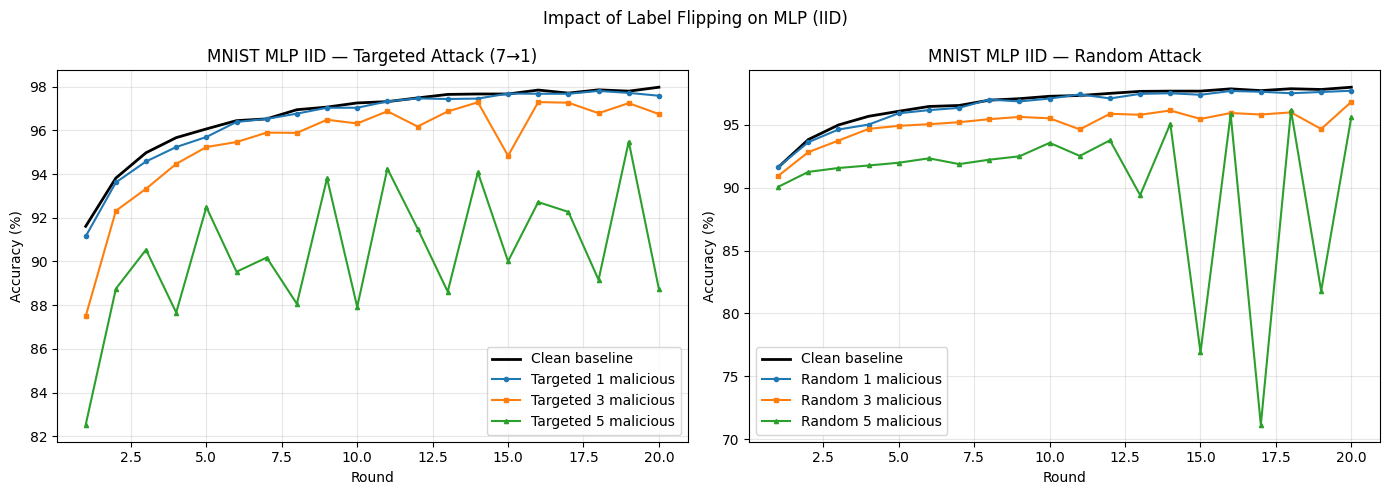

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Targeted
axes[0].plot(rounds, get_acc(mnist_mlp_iid_clean), 'k-', linewidth=2, label='Clean baseline')
axes[0].plot(rounds, get_acc(mlp_iid_t1), marker='o', markersize=3, label='Targeted 1 malicious')
axes[0].plot(rounds, get_acc(mlp_iid_t3), marker='s', markersize=3, label='Targeted 3 malicious')
axes[0].plot(rounds, get_acc(mlp_iid_t5), marker='^', markersize=3, label='Targeted 5 malicious')
axes[0].set_title('MNIST MLP IID — Targeted Attack (7→1)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random
axes[1].plot(rounds, get_acc(mnist_mlp_iid_clean), 'k-', linewidth=2, label='Clean baseline')
axes[1].plot(rounds, get_acc(mlp_iid_r1), marker='o', markersize=3, label='Random 1 malicious')
axes[1].plot(rounds, get_acc(mlp_iid_r3), marker='s', markersize=3, label='Random 3 malicious')
axes[1].plot(rounds, get_acc(mlp_iid_r5), marker='^', markersize=3, label='Random 5 malicious')
axes[1].set_title('MNIST MLP IID — Random Attack')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Impact of Label Flipping on MLP (IID)')
plt.tight_layout()
plt.savefig(os.path.join(base, 'attack_mlp_iid_accuracy.png'), dpi=150)
plt.show()

## Plot 2 — Accuracy Under Attack: MLP NonIID (Targeted vs Random)

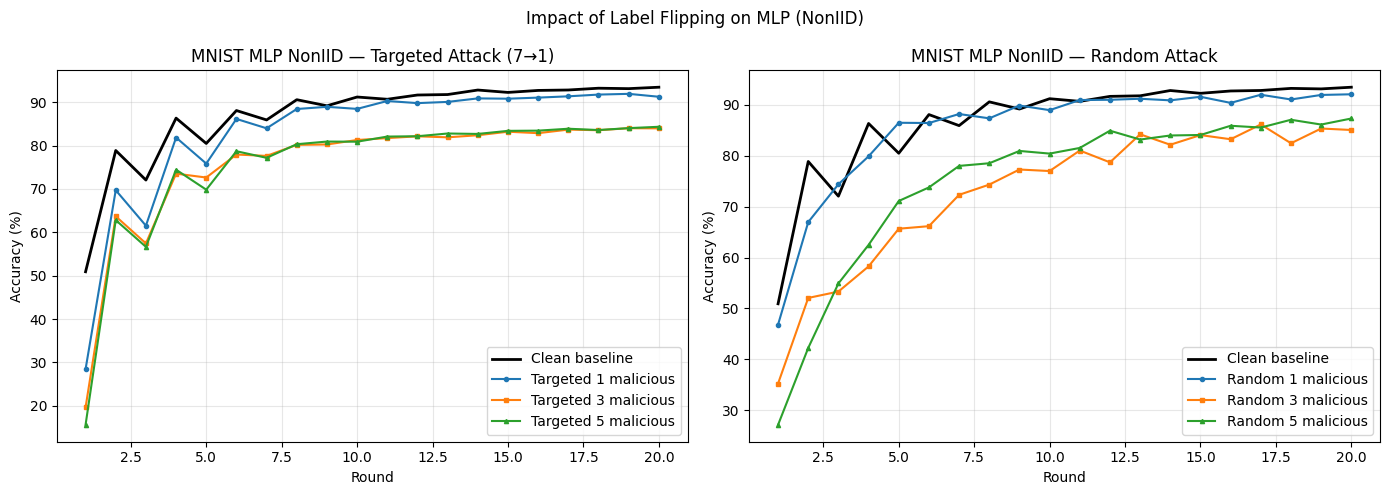

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, get_acc(mnist_mlp_noniid_clean), 'k-', linewidth=2, label='Clean baseline')
axes[0].plot(rounds, get_acc(mlp_noniid_t1), marker='o', markersize=3, label='Targeted 1 malicious')
axes[0].plot(rounds, get_acc(mlp_noniid_t3), marker='s', markersize=3, label='Targeted 3 malicious')
axes[0].plot(rounds, get_acc(mlp_noniid_t5), marker='^', markersize=3, label='Targeted 5 malicious')
axes[0].set_title('MNIST MLP NonIID — Targeted Attack (7→1)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(rounds, get_acc(mnist_mlp_noniid_clean), 'k-', linewidth=2, label='Clean baseline')
axes[1].plot(rounds, get_acc(mlp_noniid_r1), marker='o', markersize=3, label='Random 1 malicious')
axes[1].plot(rounds, get_acc(mlp_noniid_r3), marker='s', markersize=3, label='Random 3 malicious')
axes[1].plot(rounds, get_acc(mlp_noniid_r5), marker='^', markersize=3, label='Random 5 malicious')
axes[1].set_title('MNIST MLP NonIID — Random Attack')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Impact of Label Flipping on MLP (NonIID)')
plt.tight_layout()
plt.savefig(os.path.join(base, 'attack_mlp_noniid_accuracy.png'), dpi=150)
plt.show()

## Plot 3 — Accuracy Under Attack: CNN IID and NonIID

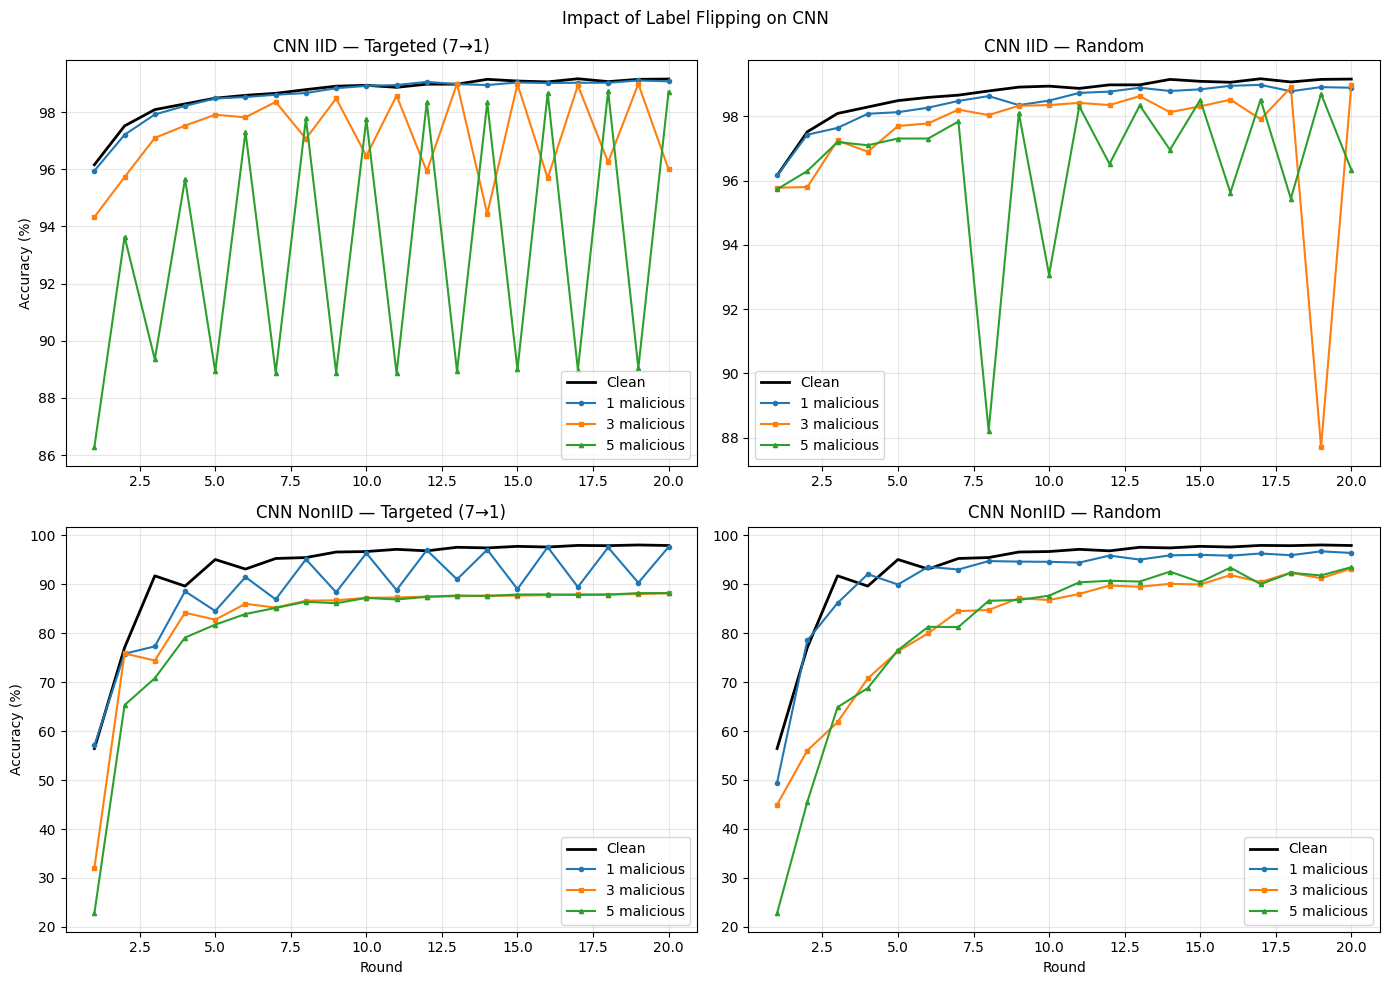

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CNN IID Targeted
axes[0][0].plot(rounds, get_acc(mnist_cnn_iid_clean), 'k-', linewidth=2, label='Clean')
axes[0][0].plot(rounds, get_acc(cnn_iid_t1), marker='o', markersize=3, label='1 malicious')
axes[0][0].plot(rounds, get_acc(cnn_iid_t3), marker='s', markersize=3, label='3 malicious')
axes[0][0].plot(rounds, get_acc(cnn_iid_t5), marker='^', markersize=3, label='5 malicious')
axes[0][0].set_title('CNN IID — Targeted (7→1)')
axes[0][0].set_ylabel('Accuracy (%)')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

# CNN IID Random
axes[0][1].plot(rounds, get_acc(mnist_cnn_iid_clean), 'k-', linewidth=2, label='Clean')
axes[0][1].plot(rounds, get_acc(cnn_iid_r1), marker='o', markersize=3, label='1 malicious')
axes[0][1].plot(rounds, get_acc(cnn_iid_r3), marker='s', markersize=3, label='3 malicious')
axes[0][1].plot(rounds, get_acc(cnn_iid_r5), marker='^', markersize=3, label='5 malicious')
axes[0][1].set_title('CNN IID — Random')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)

# CNN NonIID Targeted
axes[1][0].plot(rounds, get_acc(mnist_cnn_noniid_clean), 'k-', linewidth=2, label='Clean')
axes[1][0].plot(rounds, get_acc(cnn_noniid_t1), marker='o', markersize=3, label='1 malicious')
axes[1][0].plot(rounds, get_acc(cnn_noniid_t3), marker='s', markersize=3, label='3 malicious')
axes[1][0].plot(rounds, get_acc(cnn_noniid_t5), marker='^', markersize=3, label='5 malicious')
axes[1][0].set_title('CNN NonIID — Targeted (7→1)')
axes[1][0].set_xlabel('Round')
axes[1][0].set_ylabel('Accuracy (%)')
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3)

# CNN NonIID Random
axes[1][1].plot(rounds, get_acc(mnist_cnn_noniid_clean), 'k-', linewidth=2, label='Clean')
axes[1][1].plot(rounds, get_acc(cnn_noniid_r1), marker='o', markersize=3, label='1 malicious')
axes[1][1].plot(rounds, get_acc(cnn_noniid_r3), marker='s', markersize=3, label='3 malicious')
axes[1][1].plot(rounds, get_acc(cnn_noniid_r5), marker='^', markersize=3, label='5 malicious')
axes[1][1].set_title('CNN NonIID — Random')
axes[1][1].set_xlabel('Round')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

plt.suptitle('Impact of Label Flipping on CNN')
plt.tight_layout()
plt.savefig(os.path.join(base, 'attack_cnn_accuracy.png'), dpi=150)
plt.show()

## Plot 4 — ASR (Attack Success Rate) vs Rounds — Targeted Attack

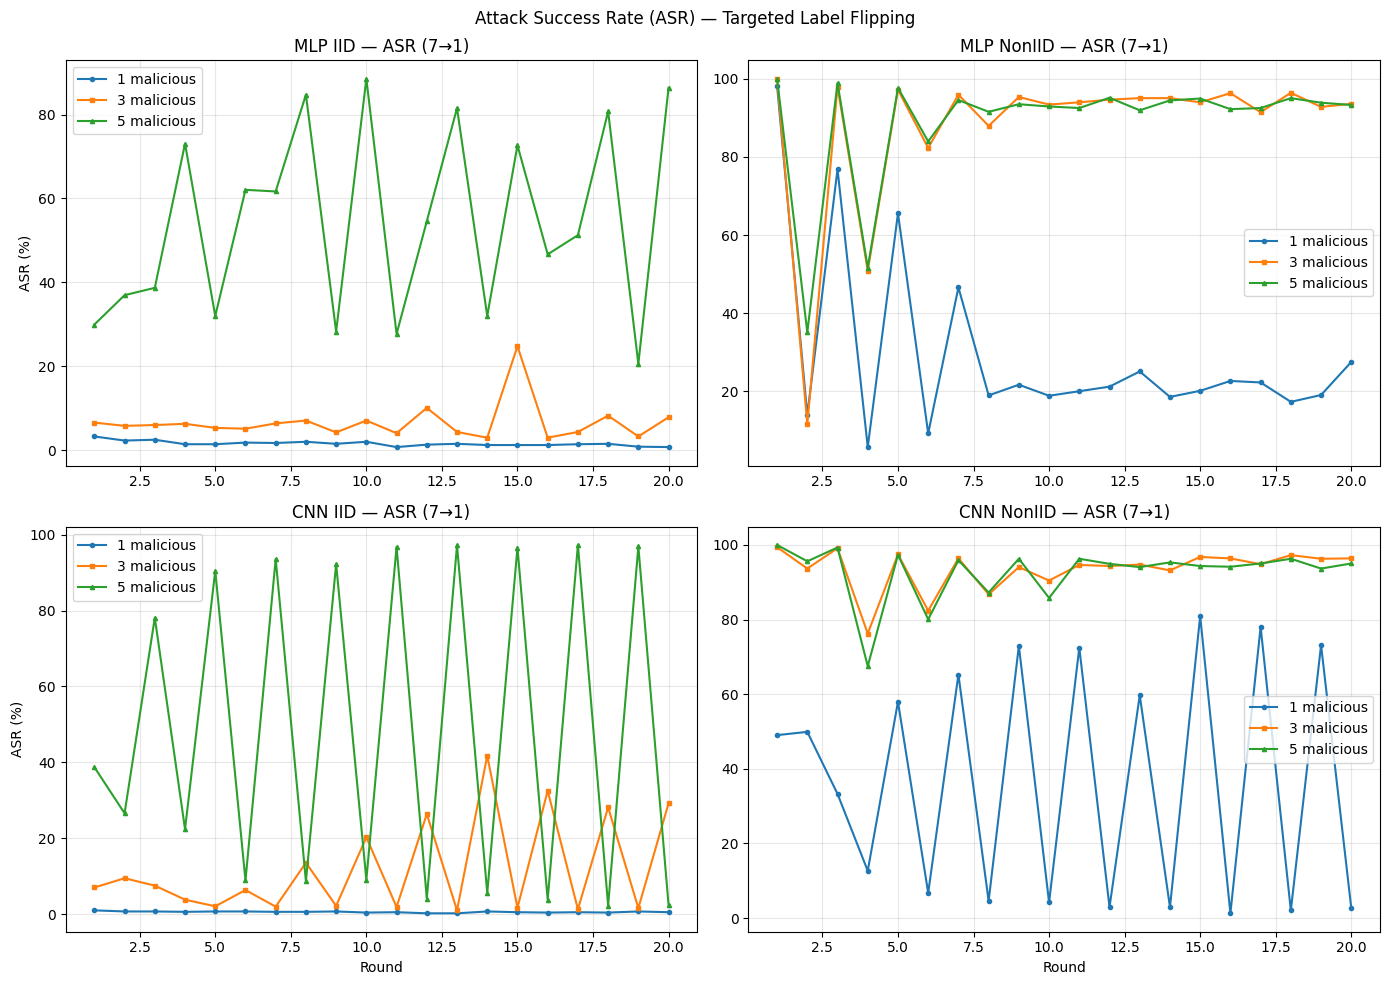

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MLP IID ASR
axes[0][0].plot(rounds, get_asr(mlp_iid_t1), marker='o', markersize=3, label='1 malicious')
axes[0][0].plot(rounds, get_asr(mlp_iid_t3), marker='s', markersize=3, label='3 malicious')
axes[0][0].plot(rounds, get_asr(mlp_iid_t5), marker='^', markersize=3, label='5 malicious')
axes[0][0].set_title('MLP IID — ASR (7→1)')
axes[0][0].set_ylabel('ASR (%)')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

# MLP NonIID ASR
axes[0][1].plot(rounds, get_asr(mlp_noniid_t1), marker='o', markersize=3, label='1 malicious')
axes[0][1].plot(rounds, get_asr(mlp_noniid_t3), marker='s', markersize=3, label='3 malicious')
axes[0][1].plot(rounds, get_asr(mlp_noniid_t5), marker='^', markersize=3, label='5 malicious')
axes[0][1].set_title('MLP NonIID — ASR (7→1)')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)

# CNN IID ASR
axes[1][0].plot(rounds, get_asr(cnn_iid_t1), marker='o', markersize=3, label='1 malicious')
axes[1][0].plot(rounds, get_asr(cnn_iid_t3), marker='s', markersize=3, label='3 malicious')
axes[1][0].plot(rounds, get_asr(cnn_iid_t5), marker='^', markersize=3, label='5 malicious')
axes[1][0].set_title('CNN IID — ASR (7→1)')
axes[1][0].set_xlabel('Round')
axes[1][0].set_ylabel('ASR (%)')
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3)

# CNN NonIID ASR
axes[1][1].plot(rounds, get_asr(cnn_noniid_t1), marker='o', markersize=3, label='1 malicious')
axes[1][1].plot(rounds, get_asr(cnn_noniid_t3), marker='s', markersize=3, label='3 malicious')
axes[1][1].plot(rounds, get_asr(cnn_noniid_t5), marker='^', markersize=3, label='5 malicious')
axes[1][1].set_title('CNN NonIID — ASR (7→1)')
axes[1][1].set_xlabel('Round')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

plt.suptitle('Attack Success Rate (ASR) — Targeted Label Flipping')
plt.tight_layout()
plt.savefig(os.path.join(base, 'attack_asr_all.png'), dpi=150)
plt.show()

## Plot 5 — Accuracy Drop vs Number of Malicious Clients (Round 20)

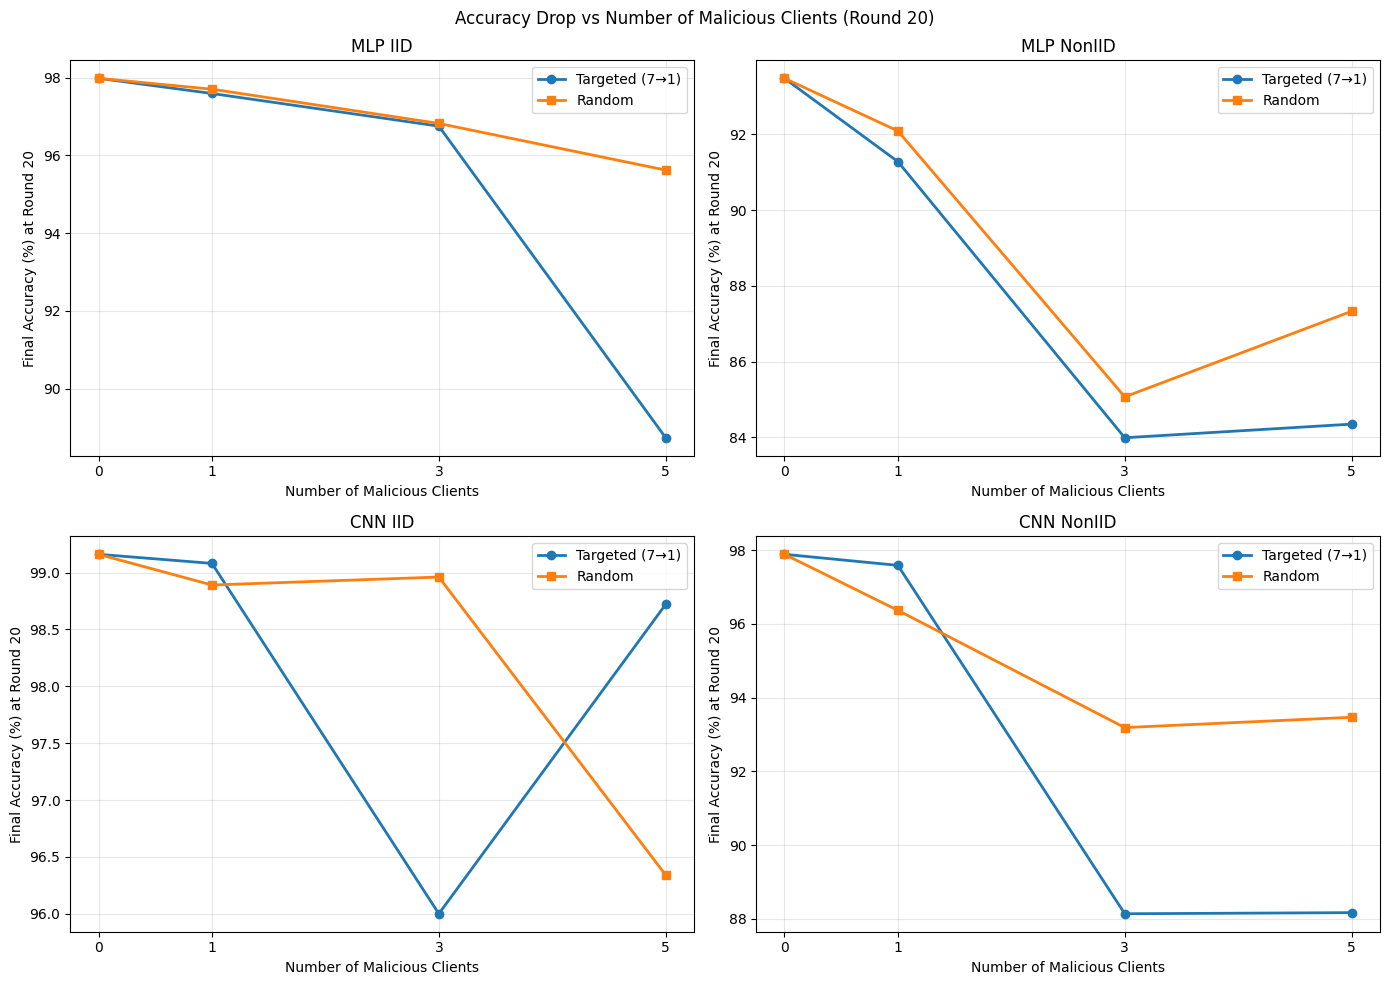

In [7]:
malicious_counts = [0, 1, 3, 5]

def final_acc(data):
    return data['accuracy'][-1][1] * 100

# MLP IID
mlp_iid_targeted = [final_acc(mnist_mlp_iid_clean), final_acc(mlp_iid_t1), final_acc(mlp_iid_t3), final_acc(mlp_iid_t5)]
mlp_iid_random   = [final_acc(mnist_mlp_iid_clean), final_acc(mlp_iid_r1), final_acc(mlp_iid_r3), final_acc(mlp_iid_r5)]

# MLP NonIID
mlp_noniid_targeted = [final_acc(mnist_mlp_noniid_clean), final_acc(mlp_noniid_t1), final_acc(mlp_noniid_t3), final_acc(mlp_noniid_t5)]
mlp_noniid_random   = [final_acc(mnist_mlp_noniid_clean), final_acc(mlp_noniid_r1), final_acc(mlp_noniid_r3), final_acc(mlp_noniid_r5)]

# CNN IID
cnn_iid_targeted = [final_acc(mnist_cnn_iid_clean), final_acc(cnn_iid_t1), final_acc(cnn_iid_t3), final_acc(cnn_iid_t5)]
cnn_iid_random   = [final_acc(mnist_cnn_iid_clean), final_acc(cnn_iid_r1), final_acc(cnn_iid_r3), final_acc(cnn_iid_r5)]

# CNN NonIID
cnn_noniid_targeted = [final_acc(mnist_cnn_noniid_clean), final_acc(cnn_noniid_t1), final_acc(cnn_noniid_t3), final_acc(cnn_noniid_t5)]
cnn_noniid_random   = [final_acc(mnist_cnn_noniid_clean), final_acc(cnn_noniid_r1), final_acc(cnn_noniid_r3), final_acc(cnn_noniid_r5)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, targeted, random, title in zip(
    axes.flatten(),
    [mlp_iid_targeted, mlp_noniid_targeted, cnn_iid_targeted, cnn_noniid_targeted],
    [mlp_iid_random,   mlp_noniid_random,   cnn_iid_random,   cnn_noniid_random],
    ['MLP IID', 'MLP NonIID', 'CNN IID', 'CNN NonIID']
):
    ax.plot(malicious_counts, targeted, marker='o', linewidth=2, label='Targeted (7→1)')
    ax.plot(malicious_counts, random,   marker='s', linewidth=2, label='Random')
    ax.set_title(title)
    ax.set_xlabel('Number of Malicious Clients')
    ax.set_ylabel('Final Accuracy (%) at Round 20')
    ax.set_xticks(malicious_counts)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Accuracy Drop vs Number of Malicious Clients (Round 20)')
plt.tight_layout()
plt.savefig(os.path.join(base, 'attack_accuracy_vs_malicious.png'), dpi=150)
plt.show()

## Plot 6 — ASR vs Number of Malicious Clients (Round 20)

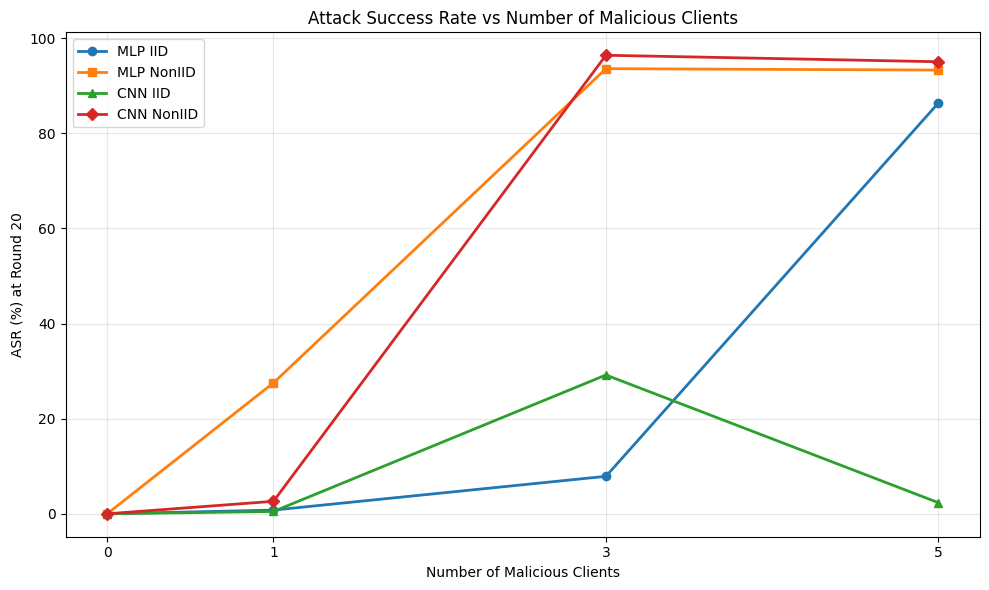

In [8]:
def final_asr(data):
    v = data['asr'][-1][1]
    return v * 100 if v is not None else 0

asr_mlp_iid    = [0, final_asr(mlp_iid_t1),    final_asr(mlp_iid_t3),    final_asr(mlp_iid_t5)]
asr_mlp_noniid = [0, final_asr(mlp_noniid_t1), final_asr(mlp_noniid_t3), final_asr(mlp_noniid_t5)]
asr_cnn_iid    = [0, final_asr(cnn_iid_t1),    final_asr(cnn_iid_t3),    final_asr(cnn_iid_t5)]
asr_cnn_noniid = [0, final_asr(cnn_noniid_t1), final_asr(cnn_noniid_t3), final_asr(cnn_noniid_t5)]

plt.figure(figsize=(10, 6))
plt.plot(malicious_counts, asr_mlp_iid,    marker='o', linewidth=2, label='MLP IID')
plt.plot(malicious_counts, asr_mlp_noniid, marker='s', linewidth=2, label='MLP NonIID')
plt.plot(malicious_counts, asr_cnn_iid,    marker='^', linewidth=2, label='CNN IID')
plt.plot(malicious_counts, asr_cnn_noniid, marker='D', linewidth=2, label='CNN NonIID')
plt.xlabel('Number of Malicious Clients')
plt.ylabel('ASR (%) at Round 20')
plt.title('Attack Success Rate vs Number of Malicious Clients')
plt.xticks(malicious_counts)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(base, 'attack_asr_vs_malicious.png'), dpi=150)
plt.show()

## Plot 7 — MLP vs CNN Attack Resistance (IID, Targeted, 3 malicious)

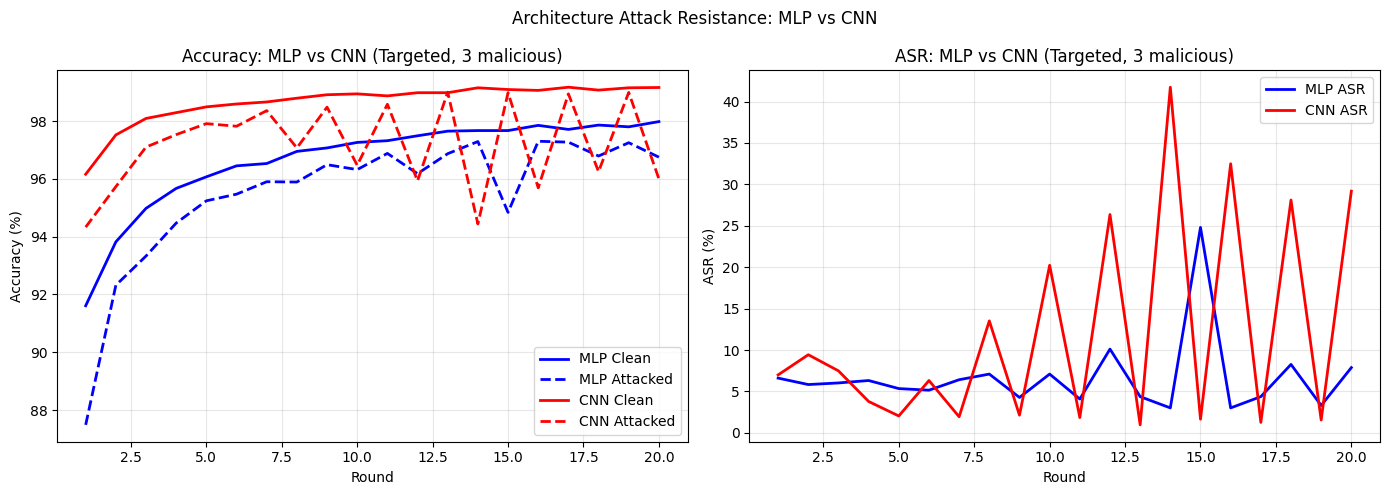

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(rounds, get_acc(mnist_mlp_iid_clean), 'b-',  linewidth=2, label='MLP Clean')
axes[0].plot(rounds, get_acc(mlp_iid_t3),          'b--', linewidth=2, label='MLP Attacked')
axes[0].plot(rounds, get_acc(mnist_cnn_iid_clean), 'r-',  linewidth=2, label='CNN Clean')
axes[0].plot(rounds, get_acc(cnn_iid_t3),          'r--', linewidth=2, label='CNN Attacked')
axes[0].set_title('Accuracy: MLP vs CNN (Targeted, 3 malicious)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ASR comparison
axes[1].plot(rounds, get_asr(mlp_iid_t3), 'b-', linewidth=2, label='MLP ASR')
axes[1].plot(rounds, get_asr(cnn_iid_t3), 'r-', linewidth=2, label='CNN ASR')
axes[1].set_title('ASR: MLP vs CNN (Targeted, 3 malicious)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('ASR (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Architecture Attack Resistance: MLP vs CNN')
plt.tight_layout()
plt.savefig(os.path.join(base, 'attack_mlp_vs_cnn_resistance.png'), dpi=150)
plt.show()

## Plot 8 — IID vs NonIID Vulnerability (MLP, Targeted, 3 malicious)

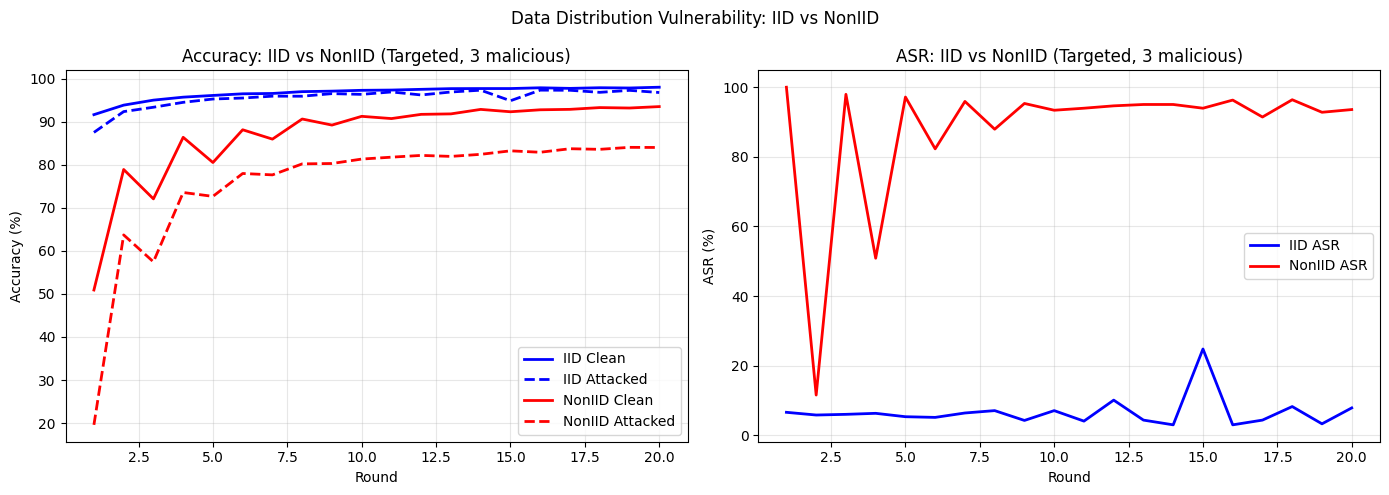

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(rounds, get_acc(mnist_mlp_iid_clean),    'b-',  linewidth=2, label='IID Clean')
axes[0].plot(rounds, get_acc(mlp_iid_t3),             'b--', linewidth=2, label='IID Attacked')
axes[0].plot(rounds, get_acc(mnist_mlp_noniid_clean), 'r-',  linewidth=2, label='NonIID Clean')
axes[0].plot(rounds, get_acc(mlp_noniid_t3),          'r--', linewidth=2, label='NonIID Attacked')
axes[0].set_title('Accuracy: IID vs NonIID (Targeted, 3 malicious)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ASR|
axes[1].plot(rounds, get_asr(mlp_iid_t3),    'b-', linewidth=2, label='IID ASR')
axes[1].plot(rounds, get_asr(mlp_noniid_t3), 'r-', linewidth=2, label='NonIID ASR')
axes[1].set_title('ASR: IID vs NonIID (Targeted, 3 malicious)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('ASR (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Data Distribution Vulnerability: IID vs NonIID')
plt.tight_layout()
plt.savefig(os.path.join(base, 'attack_iid_vs_noniid_vulnerability.png'), dpi=150)
plt.show()

## Plot 9 — Per-Class Accuracy Heatmap (MLP IID, Targeted, Round 20)

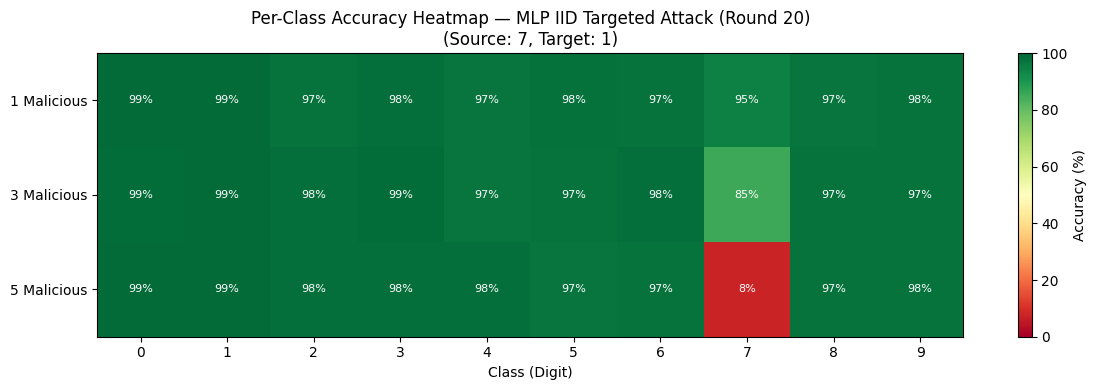

In [11]:
# Per-class heatmap — only works if new attack files with per_class_accuracy exist
per_class_data = {
    'Clean'      : get_final_per_class(mnist_mlp_iid_clean),
    '1 Malicious': get_final_per_class(mlp_iid_t1),
    '3 Malicious': get_final_per_class(mlp_iid_t3),
    '5 Malicious': get_final_per_class(mlp_iid_t5),
}

available = {k: v for k, v in per_class_data.items() if v is not None}

if len(available) < 2:
    print("Per-class accuracy not available in current JSON files.")
    print("Re-run attack configs with updated main_attack.py to get this data.")
else:
    configs = list(available.keys())
    matrix  = np.array(list(available.values()))
    class_labels = [str(i) for i in range(10)]

    fig, ax = plt.subplots(figsize=(12, 4))
    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
    plt.colorbar(im, ax=ax, label='Accuracy (%)')
    ax.set_xticks(range(10))
    ax.set_xticklabels(class_labels)
    ax.set_yticks(range(len(configs)))
    ax.set_yticklabels(configs)
    ax.set_xlabel('Class (Digit)')
    ax.set_title('Per-Class Accuracy Heatmap — MLP IID Targeted Attack (Round 20)\n(Source: 7, Target: 1)')

    for i in range(len(configs)):
        for j in range(10):
            ax.text(j, i, f'{matrix[i,j]:.0f}%', ha='center', va='center', fontsize=8,
                    color='black' if 30 < matrix[i,j] < 80 else 'white')

    plt.tight_layout()
    plt.savefig(os.path.join(base, 'attack_perclass_heatmap_mlp_iid.png'), dpi=150)
    plt.show()

## Plot 10 — EMNIST vs MNIST Attack Comparison (Cross-Dataset)

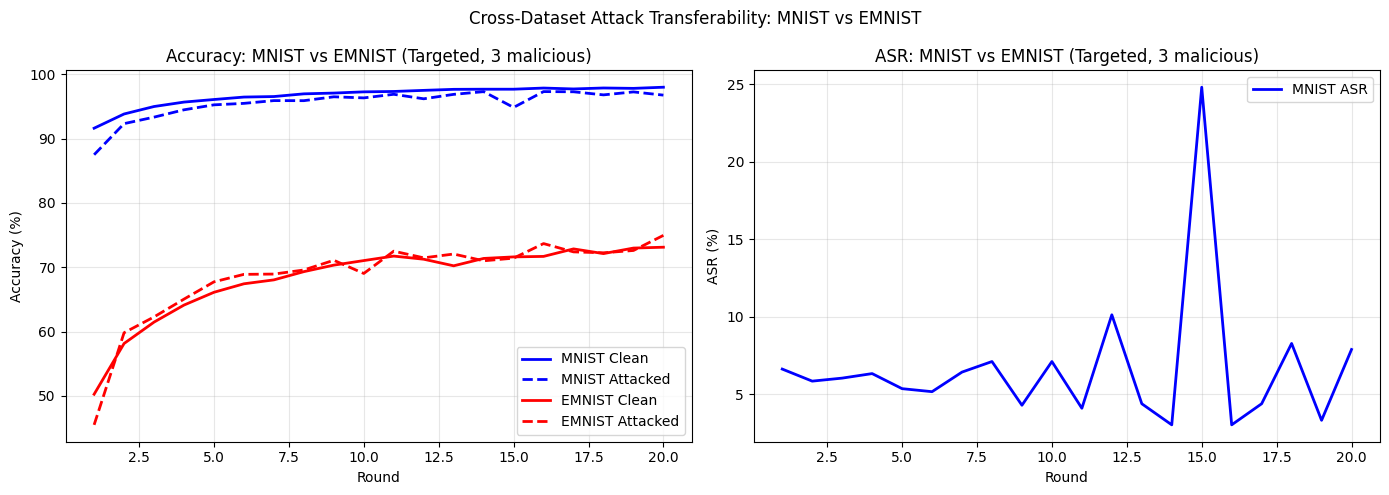

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison — always works
axes[0].plot(rounds, get_acc(mnist_mlp_iid_clean), 'b-',  linewidth=2, label='MNIST Clean')
axes[0].plot(rounds, get_acc(mlp_iid_t3),          'b--', linewidth=2, label='MNIST Attacked')
if emnist_mlp_iid_clean is not None:
    axes[0].plot(rounds, get_acc(emnist_mlp_iid_clean), 'r-',  linewidth=2, label='EMNIST Clean')
if emnist_mlp_iid_t3 is not None:
    axes[0].plot(rounds, get_acc(emnist_mlp_iid_t3),    'r--', linewidth=2, label='EMNIST Attacked')
axes[0].set_title('Accuracy: MNIST vs EMNIST (Targeted, 3 malicious)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ASR comparison — only if both have asr data
mnist_has_asr   = mlp_iid_t3 is not None and 'asr' in mlp_iid_t3
emnist_has_asr  = emnist_mlp_iid_t3 is not None and 'asr' in emnist_mlp_iid_t3

if mnist_has_asr:
    axes[1].plot(rounds, get_asr(mlp_iid_t3), 'b-', linewidth=2, label='MNIST ASR')
if emnist_has_asr:
    axes[1].plot(rounds, get_asr(emnist_mlp_iid_t3), 'r-', linewidth=2, label='EMNIST ASR')
if not mnist_has_asr and not emnist_has_asr:
    axes[1].text(10, 0.5, 'ASR data not available\nRe-run with updated main_attack.py',
                 ha='center', va='center', fontsize=11, color='gray')
axes[1].set_title('ASR: MNIST vs EMNIST (Targeted, 3 malicious)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('ASR (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Cross-Dataset Attack Transferability: MNIST vs EMNIST')
plt.tight_layout()
plt.savefig(os.path.join(base, 'attack_cross_dataset.png'), dpi=150)
plt.show()

## Plot 11  — Targeted Attack Visualization (Digit 7 → 1)

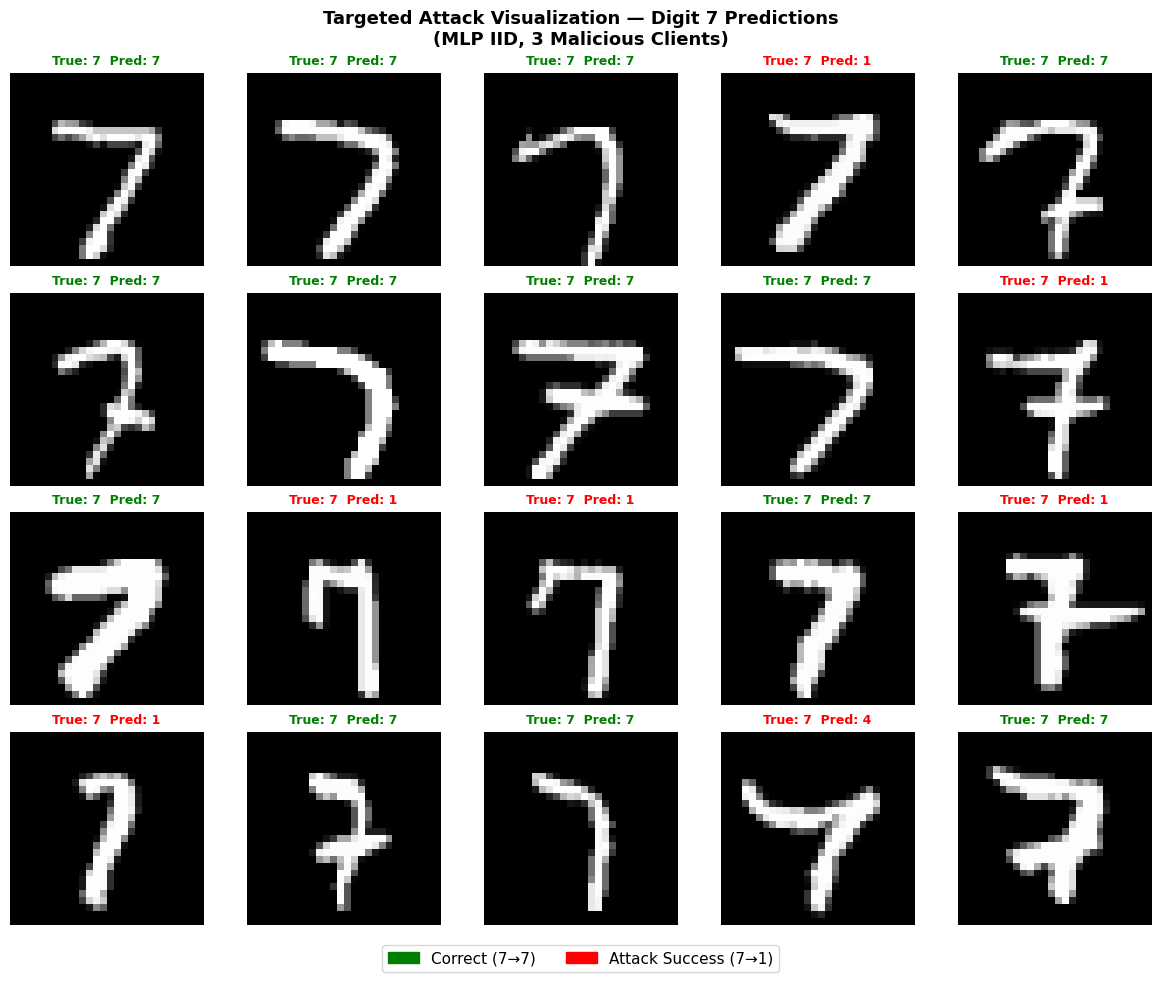

Out of 20 sevens shown:
  Correctly predicted as 7 : 13
  Flipped to 1 (attack)    : 6
  Other misclassification  : 1


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from torchvision import datasets, transforms

# ── Load model ──
class MLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model_path = os.path.join(
    base,
    "models",
    "mnist_mlp_iid_attack_targeted_5_model.pth"
)

model = MLP(num_classes=10)
model.load_state_dict(torch.load(model_path, map_location='cpu'))
model.eval()

# ── Load MNIST test set ──
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_ds = datasets.MNIST(
    root=r"E:\Me\coding\8th Sem\Final Project\Codes\Fe-Learn-Datapoisoing\data",
    train=False,
    download=False,
    transform=transform
)

# ── Find images of digit 7 ──
sevens = [(img, label) for img, label in test_ds if label == 7]

# ── Run predictions on first 20 sevens ──
results_vis = []

for img, true_label in sevens[:20]:
    with torch.no_grad():
        output = model(img.unsqueeze(0))
        predicted = output.argmax(dim=1).item()

    results_vis.append((img, true_label, predicted))

# ── Plot ──
fig, axes = plt.subplots(4, 5, figsize=(12, 10))

for i, (img, true_label, predicted) in enumerate(results_vis):
    ax = axes[i // 5][i % 5]

    ax.imshow(img.squeeze(), cmap='gray')

    color = 'red' if predicted != true_label else 'green'

    ax.set_title(
        f'True: {true_label}  Pred: {predicted}',
        color=color,
        fontsize=9,
        fontweight='bold'
    )

    ax.axis('off')

# Legend
green_patch = mpatches.Patch(
    color='green',
    label='Correct (7→7)'
)

red_patch = mpatches.Patch(
    color='red',
    label='Attack Success (7→1)'
)

fig.legend(
    handles=[green_patch, red_patch],
    loc='lower center',
    ncol=2,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.01)
)

plt.suptitle(
    'Targeted Attack Visualization — Digit 7 Predictions\n'
    '(MLP IID, 3 Malicious Clients)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(
    os.path.join(base, 'attack_visualization_7s.png'),
    dpi=150
)

plt.show()

# ── Print stats ──
correct = sum(1 for _, t, p in results_vis if p == t)

flipped = sum(1 for _, t, p in results_vis if p == 1)

other_err = sum(
    1 for _, t, p in results_vis
    if p != t and p != 1
)

print(f"Out of 20 sevens shown:")
print(f"  Correctly predicted as 7 : {correct}")
print(f"  Flipped to 1 (attack)    : {flipped}")
print(f"  Other misclassification  : {other_err}")

## Summary Table — Final Round Metrics

In [14]:
print('=' * 80)
print(f'{"Configuration":<40} {"Accuracy":>12} {"Drop":>8} {"ASR":>8}')
print('=' * 80)

rows = [
    ('MNIST MLP IID Clean',         mnist_mlp_iid_clean,    None),
    ('MNIST MLP IID Targeted 1',    mlp_iid_t1,             mlp_iid_t1),
    ('MNIST MLP IID Targeted 3',    mlp_iid_t3,             mlp_iid_t3),
    ('MNIST MLP IID Targeted 5',    mlp_iid_t5,             mlp_iid_t5),
    ('MNIST MLP IID Random 1',      mlp_iid_r1,             None),
    ('MNIST MLP IID Random 3',      mlp_iid_r3,             None),
    ('MNIST MLP IID Random 5',      mlp_iid_r5,             None),
    ('MNIST MLP NonIID Clean',      mnist_mlp_noniid_clean, None),
    ('MNIST MLP NonIID Targeted 3', mlp_noniid_t3,          mlp_noniid_t3),
    ('MNIST CNN IID Clean',         mnist_cnn_iid_clean,    None),
    ('MNIST CNN IID Targeted 3',    cnn_iid_t3,             cnn_iid_t3),
    ('MNIST CNN IID Random 3',      cnn_iid_r3,             None),
    ('MNIST CNN NonIID Clean',      mnist_cnn_noniid_clean, None),
    ('MNIST CNN NonIID Targeted 3', cnn_noniid_t3,          cnn_noniid_t3),
]

for name, acc_data, asr_data in rows:
    if acc_data is None:
        print(f'{name:<40} {"N/A":>12} {"N/A":>8} {"N/A":>8}')
        continue
    acc = final_acc(acc_data)
    if 'Clean' in name:
        drop_str = '—'
        asr_str  = '—'
    else:
        ref = final_acc(mnist_mlp_iid_clean)    if 'MLP IID' in name else \
              final_acc(mnist_mlp_noniid_clean)  if 'NonIID' in name and 'MLP' in name else \
              final_acc(mnist_cnn_iid_clean)     if 'CNN IID' in name else \
              final_acc(mnist_cnn_noniid_clean)
        drop_str = f'{ref - acc:+.2f}%'
        asr_str  = f'{final_asr(asr_data):.2f}%' if asr_data is not None else 'N/A'
    print(f'{name:<40} {acc:>11.2f}% {drop_str:>8} {asr_str:>8}')

print('=' * 80)

Configuration                                Accuracy     Drop      ASR
MNIST MLP IID Clean                            97.98%        —        —
MNIST MLP IID Targeted 1                       97.59%   +0.39%    0.78%
MNIST MLP IID Targeted 3                       96.75%   +1.23%    7.88%
MNIST MLP IID Targeted 5                       88.74%   +9.24%   86.38%
MNIST MLP IID Random 1                         97.70%   +0.28%      N/A
MNIST MLP IID Random 3                         96.82%   +1.16%      N/A
MNIST MLP IID Random 5                         95.62%   +2.36%      N/A
MNIST MLP NonIID Clean                         93.48%        —        —
MNIST MLP NonIID Targeted 3                    83.99%   +9.49%   93.58%
MNIST CNN IID Clean                            99.16%        —        —
MNIST CNN IID Targeted 3                       96.00%   +3.16%   29.18%
MNIST CNN IID Random 3                         98.96%   +0.20%      N/A
MNIST CNN NonIID Clean                         97.89%        —  